# MICrONS edge effect: Reimann heuristic vs. bosperrus

Three-panel figure for the manuscript:
- **A** · Indegree, outdegree and degree vs. distance to boundary (log y), with piecewise-linear fits and elbows.
- **B** · Outer synapse fraction (Reimann's metric) vs. distance to boundary; blue = bosperrus-affected, gray = bosperrus-safe; red dashed = Reimann 5% threshold, blue dashed = bosperrus elbow.
- **C** · Spatial map (z–x) with bosperrus elbow polygon overlay; Reimann-safe neurons in red.

In [14]:
import numpy as np
import alphashape
import shapely
from shapely.geometry import Point
import pandas as pd
import conntility
import bosperrus
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc
import seaborn as sns

FN_MAT = "/data/bionets/je30bery/bosperrus-experiments/reimann_data/microns_mm3_connectome.h5"
SAVE_PATH = "/data/bionets/je30bery/bosperrus-manuscript/figures/fig_microns_buffer.pdf"

REIMANN_THRESH = 0.05  # Reimann's reported safe threshold

In [2]:
M = conntility.ConnectivityMatrix.from_h5(FN_MAT, "full")

In [3]:
nbins = 51
extents = {}
for col in ["x_nm", "z_nm"]:
    bins = np.linspace(M.edges[col].min(), M.edges[col].max() + 1, nbins)
    extents[col] = [bins[0] / 1000, bins[-1] / 1000]
    M.add_edge_property(col + f"_binned_{nbins}", np.digitize(M.edges[col], bins=bins))
    M.add_vertex_property(col + f"_binned_{nbins}", np.digitize(M.vertices[col], bins=bins))

# synapse density per 2D bin
I = (M.edges
     .groupby(["x_nm_binned_51", "z_nm_binned_51"])["id"]
     .count()
     .unstack("x_nm_binned_51"))

# define border bins
edge_idxx = pd.MultiIndex.from_frame(M.edges[["z_nm_binned_51", "x_nm_binned_51"]])
is_outer = I.stack().rename("count").reset_index()
is_outer["outer"] = (
    (is_outer["count"] < 1000) |
    (is_outer["z_nm_binned_51"] <= 3) |
    (is_outer["z_nm_binned_51"] >= (nbins - 3))
)
is_outer = is_outer.set_index(["z_nm_binned_51", "x_nm_binned_51"])["outer"]
M.add_edge_property("syn_in_outer_bin", is_outer[edge_idxx].values)

# compress to one edge per neuron pair, sum outer-bin synapses
C = M.compress({"outer_bin_count": ("syn_in_outer_bin", "sum")})

outer_per_neuron = np.array(C.default("outer_bin_count").matrix.sum(axis=0))[0]
outer_syn_fraction = outer_per_neuron / C.vertices["indegree"].values
C.add_vertex_property("outer_syn_fraction", outer_syn_fraction)

/tmp/ipykernel_3657973/3556225964.py:30: RuntimeWarning: invalid value encountered in divide
  outer_syn_fraction = outer_per_neuron / C.vertices["indegree"].values


In [4]:
coords_xz = M.vertices[["x_nm", "z_nm"]].values
alpha_shape = alphashape.alphashape(coords_xz, alpha=0.0001)  # tune alpha

alpha_distances = np.array([
    alpha_shape.boundary.distance(Point(x, z))
    for x, z in coords_xz
])

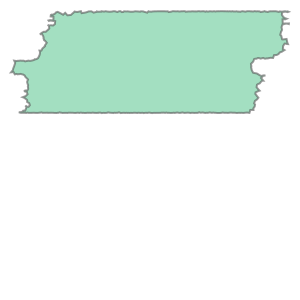

In [5]:
alpha_shape

In [6]:
scores = M.vertices[["indegree", "outdegree"]]
scores["degree"] = scores[["indegree", "outdegree"]].sum(axis=1)

In [7]:
flow = bosperrus.Flow.from_distances_and_scores(
            distances=pd.Series(alpha_distances, name="alpha_distance"),
            scores=scores,
    )
flow.flow(fits=[bosperrus.PiecewiseLinearFit, bosperrus.ConstantFit],
            baseline_fit_class=bosperrus.ConstantFit)

In [8]:
# elbows per score (nm)
elbows = {s: flow.best_fits[s].params["piecewise_linear_b"] for s in ["indegree", "outdegree", "degree"]}

# comparison DataFrame — use indegree elbow for the binary bosperrus label
# (matching Reimann which is also based on afferent synapses)
elbow = elbows["indegree"]

df = M.vertices[["x_nm", "z_nm"]].copy()
df["outer_syn_fraction"] = C.vertices["outer_syn_fraction"].values
df["bosperrus_distance"]  = alpha_distances
df = df.dropna(subset=["outer_syn_fraction"])

df["reimann_affected"]   = df["outer_syn_fraction"] > REIMANN_THRESH
df["bosperrus_affected"] = df["bosperrus_distance"]  < elbow

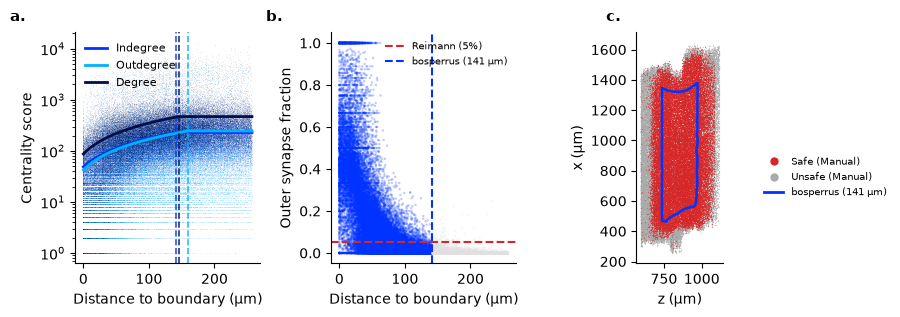

In [9]:
# ── colour palette ────────────────────────────────────────────────────────────
C_IND  = "#0033FF"   # indegree / bosperrus
C_OUT  = "#00B2FF"   # outdegree
C_DEG  = "#000E47"   # degree

SCORE_COLORS = {"indegree": C_IND, "outdegree": C_OUT, "degree": C_DEG}
SCORE_LABELS = {"indegree": "Indegree", "outdegree": "Outdegree", "degree": "Degree"}

C_SAFE   = "#d62728"  # red  – Reimann threshold / Reimann-safe neurons
C_UNSAFE = "#aaaaaa"  # gray – unsafe by both
C_BG     = "#e0e0e0"  # light gray – bosperrus-safe

# ── boolean masks (shared by panels B and C) ──────────────────────────────────
both_unsafe    = df["bosperrus_affected"] &  df["reimann_affected"]
bosperrus_only = df["bosperrus_affected"] & ~df["reimann_affected"]
reimann_only   = df["reimann_affected"]   & ~df["bosperrus_affected"]

# ── figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 3))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A · centrality scores vs distance to boundary, with piecewise fits
# ══════════════════════════════════════════════════════════════════════════════
d_sorted = np.sort(alpha_distances)

for score in ["indegree", "outdegree", "degree"]:
    b = elbows[score]
    m = flow.best_fits[score].params["piecewise_linear_m"]
    c = flow.best_fits[score].params["piecewise_linear_c"]
    col = SCORE_COLORS[score]

    ax1.scatter(alpha_distances / 1e3, scores[score],
                s=0.4, alpha=0.06, color=col, linewidths=0, rasterized=True)
    y_fit = bosperrus.PiecewiseLinearFit.piecewise_plateau(d_sorted, b=b, m=m, c=c)
    ax1.plot(d_sorted / 1e3, y_fit, color=col, lw=2, label=SCORE_LABELS[score])
    ax1.axvline(b / 1e3, color=col, lw=1.2, ls="--", alpha=0.85)

ax1.set_yscale("log")
ax1.set_xlabel("Distance to boundary (µm)")
ax1.set_ylabel("Centrality score")
ax1.legend(fontsize=8, markerscale=6, frameon=False)
ax1.spines[["top", "right"]].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Panel B · outer synapse fraction vs. distance to boundary
# ══════════════════════════════════════════════════════════════════════════════
colors_b = np.where(df["bosperrus_affected"], C_IND, C_BG)

ax2.scatter(df["bosperrus_distance"] / 1e3, df["outer_syn_fraction"],
            c=colors_b, s=3, alpha=0.25, linewidths=0, rasterized=True)

ax2.axhline(REIMANN_THRESH, color=C_SAFE, lw=1.5, ls="--",
            label=f"Reimann ({int(REIMANN_THRESH * 100)}%)")
ax2.axvline(elbow / 1e3, color=C_IND, lw=1.5, ls="--",
            label=f"bosperrus ({elbow / 1e3:.0f} µm)")

ax2.set_xlabel("Distance to boundary (µm)")
ax2.set_ylabel("Outer synapse fraction")
ax2.legend(fontsize=7, frameon=False)
ax2.spines[["top", "right"]].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C · spatial map (z on x-axis, x on y-axis)
# ══════════════════════════════════════════════════════════════════════════════
reimann_safe = ~df["reimann_affected"]
bg           =  df["reimann_affected"] & ~df["bosperrus_affected"]

kw = dict(linewidths=0, rasterized=True)
ax3.scatter(df.loc[bg,           "z_nm"] / 1e3, df.loc[bg,           "x_nm"] / 1e3,
            s=0.6, alpha=0.4, color=C_BG, **kw)
ax3.scatter(df.loc[both_unsafe,  "z_nm"] / 1e3, df.loc[both_unsafe,  "x_nm"] / 1e3,
            s=0.8, alpha=0.5, color=C_UNSAFE, **kw)
ax3.scatter(df.loc[reimann_safe, "z_nm"] / 1e3, df.loc[reimann_safe, "x_nm"] / 1e3,
            s=0.8, alpha=0.5, color=C_SAFE, **kw)

elbow_poly = alpha_shape.buffer(-elbow)

def _plot_poly_boundary(ax, geom, **kwargs):
    polys = list(geom.geoms) if hasattr(geom, "geoms") else [geom]
    for p in polys:
        if hasattr(p, "exterior"):
            coords = np.array(p.exterior.coords)
            ax.plot(coords[:, 1] / 1e3, coords[:, 0] / 1e3, **kwargs)

if not elbow_poly.is_empty:
    _plot_poly_boundary(ax3, elbow_poly, color=C_IND, lw=1.8,
                        label=f"bosperrus ({elbow / 1e3:.0f} µm)")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_SAFE,
           markersize=7, label="Safe (Manual)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_UNSAFE,
           markersize=7, label="Unsafe (Manual)"),
    Line2D([0], [0], color=C_IND, lw=2,
           label=f"bosperrus ({elbow / 1e3:.0f} µm)"),
]
ax3.legend(handles=legend_handles, fontsize=7, frameon=False, bbox_to_anchor=(3, 0.5))
ax3.set_xlabel("z (µm)")
ax3.set_ylabel("x (µm)")
ax3.set_aspect("equal")
ax3.spines[["top", "right"]].set_visible(False)

# ── panel labels ──────────────────────────────────────────────────────────────
for ax, label in zip([ax1, ax2, ax3], ["a.", "b.", "c."]):
    ax.text(-0.35, 1.1, label, transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

import os
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
fig.savefig(SAVE_PATH, bbox_inches="tight", dpi=300)
plt.show()

In [19]:
df

,x_nm,z_nm,outer_syn_fraction,bosperrus_distance,reimann_affected,bosperrus_affected
3,1506624,746000,1.000000,0.000000,True,True
6,707264,702560,0.006803,106698.307840,False,True
7,572608,1054320,0.078740,48582.284178,True,True
8,839040,1045320,0.076142,65820.025646,True,True
9,446528,817520,0.000000,89423.026654,False,True
...,...,...,...,...,...,...
60043,692544,837240,0.000000,240606.194268,False,False
60044,747456,863800,0.000000,246784.121499,False,False
60045,723456,629040,0.275362,32961.390174,True,True
60046,906944,913360,0.000000,194326.017363,False,False


<Axes: ylabel='bosperrus_distance'>

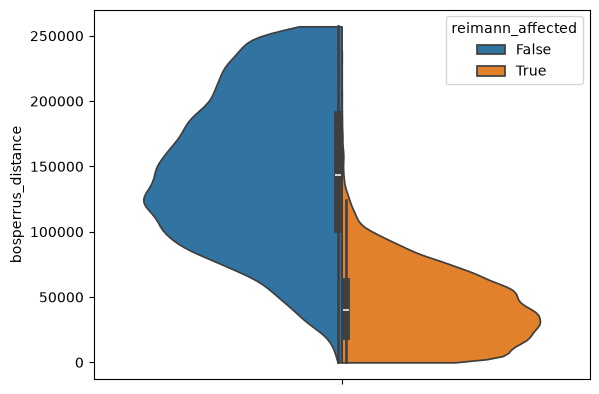

In [21]:
sns.violinplot(df, y="bosperrus_distance", hue="reimann_affected", split=True, cut=0)
